# Laufzeit-, Kosten- und Effizienzanalyse (Abschnitt 4.5 der Arbeit)

Dieses Notebook fasst `results/laufzeit_kosten_log.csv` zusammen, das von allen acht
Experiment-Notebooks (Forschungsfrage 1-4, jeweils klassisch und LLM) automatisch
befüllt wird. **Bitte erst ausführen, nachdem alle acht Notebooks - inklusive der
LLM-Notebooks mit echtem `ANTHROPIC_API_KEY` - mindestens einmal gelaufen sind.**
Andernfalls fehlen die Claude-Zeilen (Tokens/Kosten) in der Auswertung.


## 1. Log laden

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_path = "results/laufzeit_kosten_log.csv"
if not os.path.exists(log_path):
    raise FileNotFoundError(
        "results/laufzeit_kosten_log.csv existiert noch nicht - bitte zuerst mindestens "
        "eines der Experiment-Notebooks ausführen."
    )

log = pd.read_csv(log_path)
log["is_llm"] = log["method"].eq("Claude_LLM")

expected = {
    "TF1_Duplikate", "TF2_FehlendeWerte_price", "TF2_FehlendeWerte_parent_category",
    "TF3_Formatierung_price", "TF3_Formatierung_saving", "TF3_Formatierung_date",
    "TF4_Semantik",
}
missing = expected - set(log["experiment"])
if missing:
    print(f"HINWEIS: Noch keine Log-Einträge für: {sorted(missing)} - betroffene Notebooks ausführen.")

log


,experiment,method,n_items,wall_time_sec,input_tokens,output_tokens,estimated_cost_usd,model_name,is_llm
0,TF1_Duplikate,XGBoost,148,0.529222,0,0,0.0,xgboost,False
1,TF2_FehlendeWerte_price,RandomForest,164,1.600660,0,0,0.0,random_forest,False
2,TF2_FehlendeWerte_parent_category,RandomForest,125,0.595412,0,0,0.0,random_forest,False
3,TF3_Formatierung_price,XGBoost_Parser,257,0.097728,0,0,0.0,xgboost_parser,False
4,TF3_Formatierung_saving,XGBoost_Parser,149,0.054925,0,0,0.0,xgboost_parser,False
5,TF3_Formatierung_date,Regelbasierter_Parser,885,0.085928,0,0,0.0,regex_parser,False
6,TF4_Semantik,TFIDF_RandomForest,124,0.651434,0,0,0.0,tfidf_random_forest,False


## 2. Klassisch vs. LLM: Laufzeit und geschätzte Kosten je Teilaufgabe

In [2]:
summary = log[["experiment", "method", "n_items", "wall_time_sec",
                "input_tokens", "output_tokens", "estimated_cost_usd", "model_name"]].copy()
summary["sec_per_item"] = summary["wall_time_sec"] / summary["n_items"].replace(0, pd.NA)
summary = summary.sort_values(["experiment", "method"])
summary


,experiment,method,n_items,wall_time_sec,input_tokens,output_tokens,estimated_cost_usd,model_name,sec_per_item
0,TF1_Duplikate,XGBoost,148,0.529222,0,0,0.0,xgboost,0.003576
2,TF2_FehlendeWerte_parent_category,RandomForest,125,0.595412,0,0,0.0,random_forest,0.004763
1,TF2_FehlendeWerte_price,RandomForest,164,1.600660,0,0,0.0,random_forest,0.009760
5,TF3_Formatierung_date,Regelbasierter_Parser,885,0.085928,0,0,0.0,regex_parser,0.000097
3,TF3_Formatierung_price,XGBoost_Parser,257,0.097728,0,0,0.0,xgboost_parser,0.000380
4,TF3_Formatierung_saving,XGBoost_Parser,149,0.054925,0,0,0.0,xgboost_parser,0.000369
6,TF4_Semantik,TFIDF_RandomForest,124,0.651434,0,0,0.0,tfidf_random_forest,0.005253


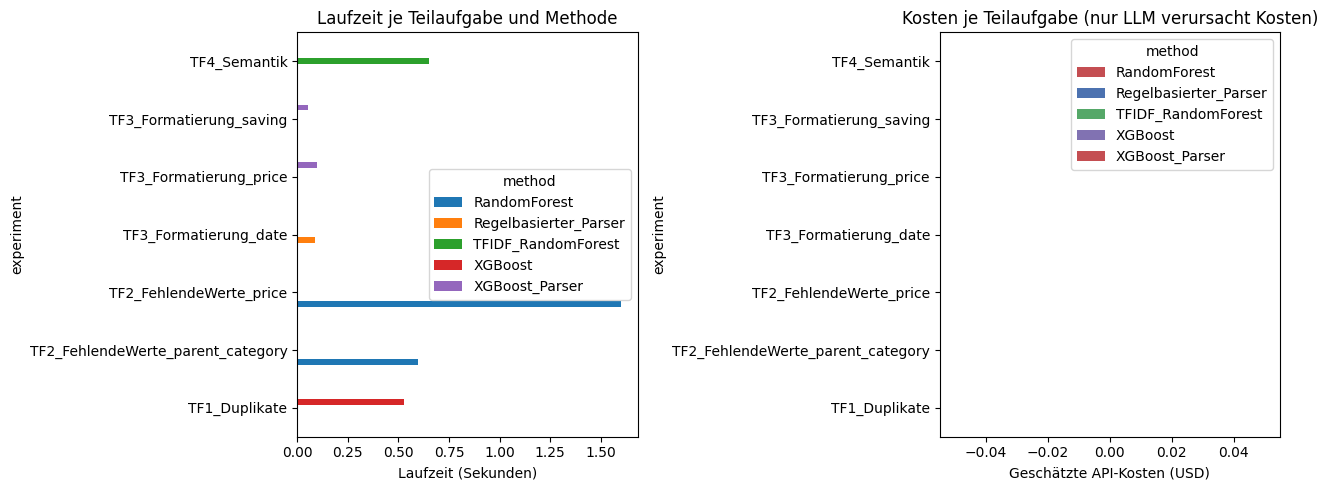

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot_time = log.pivot_table(index="experiment", columns="method", values="wall_time_sec", aggfunc="sum")
pivot_time.plot(kind="barh", ax=axes[0])
axes[0].set_xlabel("Laufzeit (Sekunden)")
axes[0].set_title("Laufzeit je Teilaufgabe und Methode")

pivot_cost = log.pivot_table(index="experiment", columns="method", values="estimated_cost_usd", aggfunc="sum")
pivot_cost.plot(kind="barh", ax=axes[1], color=["#C44E52", "#4C72B0", "#55A868", "#8172B2"])
axes[1].set_xlabel("Geschätzte API-Kosten (USD)")
axes[1].set_title("Kosten je Teilaufgabe (nur LLM verursacht Kosten)")

plt.tight_layout()
plt.show()


## 3. Token-Verbrauch (nur LLM-Methoden)

In [4]:
llm_log = log[log["method"] == "Claude_LLM"]
if len(llm_log) == 0:
    print("Noch keine LLM-Log-Einträge vorhanden.")
else:
    token_summary = llm_log[["experiment", "n_items", "input_tokens", "output_tokens", "estimated_cost_usd"]].copy()
    token_summary["tokens_per_item"] = (token_summary["input_tokens"] + token_summary["output_tokens"]) / token_summary["n_items"]
    print(token_summary.to_string(index=False))
    print()
    print(f"GESAMTKOSTEN über alle LLM-Teilaufgaben: ${llm_log['estimated_cost_usd'].sum():.4f}")
    print(f"GESAMT-TOKENS: {llm_log['input_tokens'].sum() + llm_log['output_tokens'].sum():,}")


Noch keine LLM-Log-Einträge vorhanden.


## 4. Gesamtvergleich: Skalierbarkeit

Hochrechnung: Wie würden sich Laufzeit und Kosten verändern, wenn der volle
Rohdatensatz (1326 Zeilen statt der Benchmark-Stichproben) bereinigt werden müsste?
Relevant für Abschnitt 4.5.3 (Skalierbarkeit) und die Diskussion in Abschnitt 5.3.


In [5]:
FULL_DATASET_SIZE = 1326

scaling = log[["experiment", "method", "n_items", "wall_time_sec", "estimated_cost_usd"]].copy()
scaling["scale_factor"] = FULL_DATASET_SIZE / scaling["n_items"]
scaling["hochgerechnete_laufzeit_sec"] = scaling["wall_time_sec"] * scaling["scale_factor"]
scaling["hochgerechnete_kosten_usd"] = scaling["estimated_cost_usd"] * scaling["scale_factor"]
scaling[["experiment", "method", "n_items", "hochgerechnete_laufzeit_sec", "hochgerechnete_kosten_usd"]]


,experiment,method,n_items,hochgerechnete_laufzeit_sec,hochgerechnete_kosten_usd
0,TF1_Duplikate,XGBoost,148,4.741547,0.0
1,TF2_FehlendeWerte_price,RandomForest,164,12.941920,0.0
2,TF2_FehlendeWerte_parent_category,RandomForest,125,6.316128,0.0
3,TF3_Formatierung_price,XGBoost_Parser,257,0.504232,0.0
4,TF3_Formatierung_saving,XGBoost_Parser,149,0.488797,0.0
5,TF3_Formatierung_date,Regelbasierter_Parser,885,0.128746,0.0
6,TF4_Semantik,TFIDF_RandomForest,124,6.966138,0.0
